In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('F','PWR'), 
         ('F','BK'), 
         ('F','CMI'), 
         ('STX','PWR'), 
         ('STX', 'BK'),
         ('STX', 'CMI'), 
         ('MO','PWR'), 
         ('MO', 'BK'), 
         ('MO','CMI')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

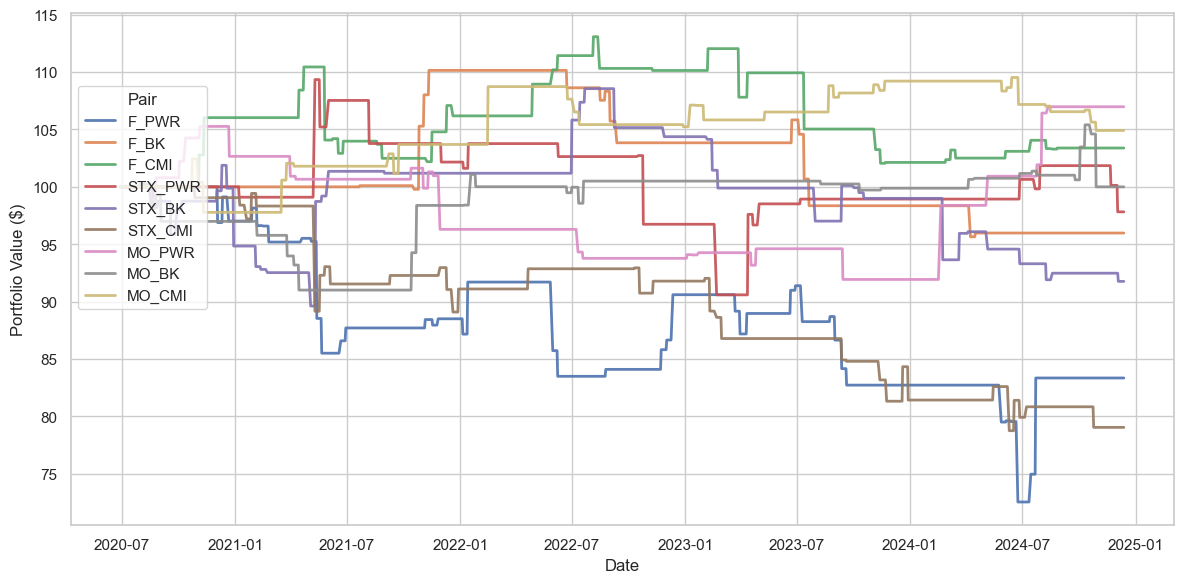

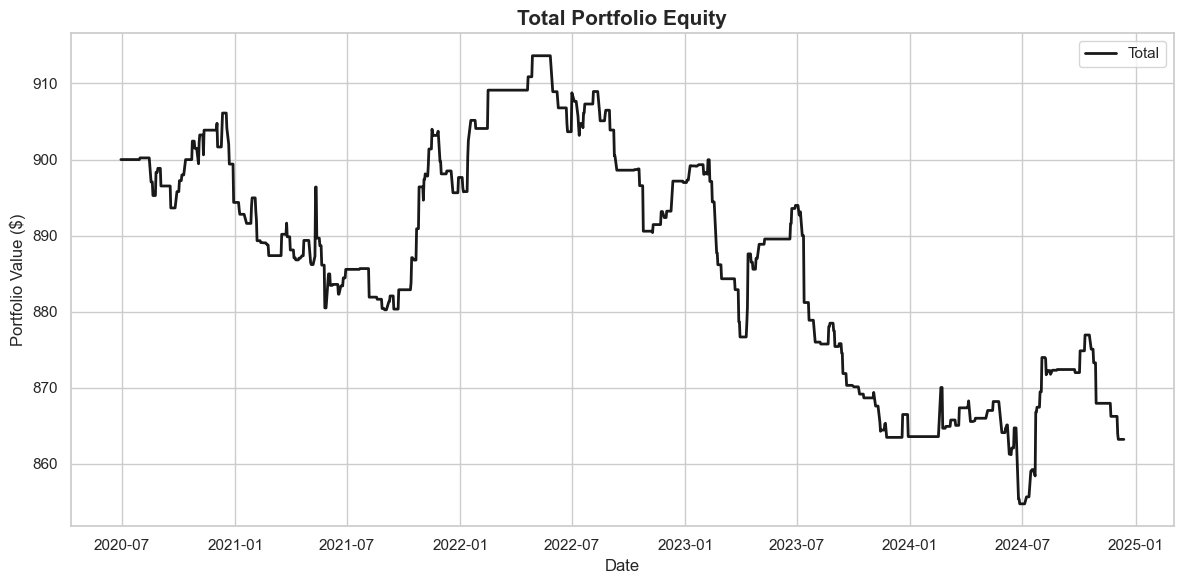

Summary
F_PWR: Final Value = $83.35, Total Return = -16.65%, Trades = 40
F_BK: Final Value = $95.98, Total Return = -4.02%, Trades = 16
F_CMI: Final Value = $103.38, Total Return = 3.38%, Trades = 35
STX_PWR: Final Value = $97.82, Total Return = -2.18%, Trades = 21
STX_BK: Final Value = $91.77, Total Return = -8.23%, Trades = 38
STX_CMI: Final Value = $79.05, Total Return = -20.95%, Trades = 34
MO_PWR: Final Value = $106.98, Total Return = 6.98%, Trades = 26
MO_BK: Final Value = $100.00, Total Return = 0.00%, Trades = 30
MO_CMI: Final Value = $104.91, Total Return = 4.91%, Trades = 33

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $863.23
Total Return:            -4.09%

Sharpe Ratios
F_PWR: Sharpe Ratio = -0.35
F_BK: Sharpe Ratio = -0.19
F_CMI: Sharpe Ratio = 0.16
STX_PWR: Sharpe Ratio = -0.02
STX_BK: Sharpe Ratio = -0.20
STX_CMI: Sharpe Ratio = -0.69
MO_PWR: Sharpe Ratio = 0.30
MO_BK: Sharpe Ratio = 0.02
MO_CMI: Sharpe Ratio = 0.27

Total Portf

In [6]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)